<a href="https://colab.research.google.com/github/esetafinau-gif/AAI2025/blob/2026fall/Part_3_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

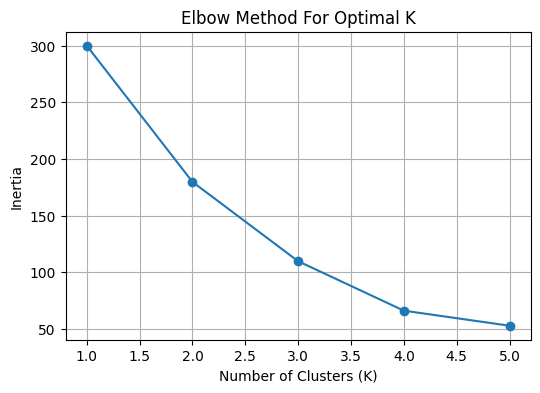

--- Cluster Analysis (Mean Characteristics) ---
         annual_income_k  spending_score
Cluster                                 
0              95.137255       14.549020
1              50.173077       63.480769
2             124.468085       69.297872


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Data Source: Synthetic Customer Segmentation Dataset (150+ records)
np.random.seed(42)
n = 150

spending_score = np.random.randint(1, 100, size=n)
annual_income = np.random.randint(15, 150, size=n)

df_kmeans = pd.DataFrame(
    {"annual_income_k": annual_income, "spending_score": spending_score}
)

# 1. Scale Features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_kmeans)

# 2. Elbow Method (Inertia for K=1 to 5)
inertia = []
K_range = range(1, 6)
for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(scaled_features)
  inertia.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method For Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.savefig("elbow_plot.png")
plt.show()

# 3. Apply K-Means Clustering with K=3
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df_kmeans["Cluster"] = kmeans_model.fit_predict(scaled_features)

# 4. Print Mean Characteristics for Each Cluster
print("--- Cluster Analysis (Mean Characteristics) ---")
cluster_summary = df_kmeans.groupby("Cluster").mean()
print(cluster_summary)

# Save Cluster Assignments to CSV
df_kmeans.to_csv("customer_segments.csv", index=False)

# Data Source: Synthetic Customer Segmentation Dataset